In [23]:
# Importar librerías
import tensorflow as tf
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

print("Versión de TensorFlow:", tf.__version__)
print("Dispositivos GPU disponibles:", tf.config.list_physical_devices('GPU'))

Versión de TensorFlow: 2.21.0
Dispositivos GPU disponibles: []


In [24]:
 #Visualización del dataframe
df = pd.read_csv("dataset_neuroflex.csv")
df.head()

,FechaObservacion,ManoPredominante,TiempoRespuestaPararse,Precision,TiempoActivoTarea,TasaAbandono,CantAciertasTotales,CantAciertosAntesError,ObjetosInteractuadosCorrectamente,TiempoRespuestaPregunta1,TiempoRespuestaPregunta2,TiempoRespuestaPregunta3,TiempoReaccionVisual,TiempoCapturarNumero,TiempoTutorial,TipoEscena,Edad,DeterioroCognitivo
0,2024-12-07 00:02:11.672693,1,2.734269,1.237033,213.160777,NaN,10,1,6,2.266641,3.431041,4.354312,0.503851,1.648153,88.897130,2,4,No
1,2025-06-15 00:02:11.672693,2,3.000330,0.467990,184.202878,NaN,8,4,5,1.579148,3.987767,5.134316,0.947702,2.392713,65.627513,2,4,Sí
2,2024-07-23 00:02:11.672693,2,2.924157,0.825931,189.308484,NaN,7,2,5,4.307494,3.374404,2.897742,0.802326,2.707416,30.000000,1,4,No
3,2024-10-27 00:02:11.672693,2,4.179060,0.887279,188.329316,2.0,2,2,4,1.178014,2.295121,5.939277,1.470080,2.864092,66.170878,1,4,Sí
4,2024-08-21 00:02:11.672693,1,2.509757,0.759653,193.058795,3.0,5,4,2,3.261734,5.246680,2.668875,0.857541,1.332367,58.832809,1,4,Sí


In [25]:
print(f"El dataframe contiene {df.shape[0]} filas y {df.shape[1]} columnas.")


El dataframe contiene 4022 filas y 18 columnas.


In [26]:

# Definir las columnas que se van a clasificar
columnas_clasificadas = [
    'TiempoRespuestaPararse',
    'TiempoRespuestaPregunta1',
    'TiempoRespuestaPregunta2',
    'TiempoRespuestaPregunta3',
    'TiempoReaccionVisual',
    'TiempoCapturarNumero'
]


np.random.seed(42)

# Cuántos registros nuevos generar por clase
filas_por_clase = 10000
filas_actuales_si = 2011
filas_actuales_no = 2011

nuevos_si = filas_por_clase - filas_actuales_si  # 7989 registros nuevos con deterioro
nuevos_no = filas_por_clase - filas_actuales_no  # 7989 registros nuevos sin deterioro


# Estadísticas reales de cada columna para respetar media y desviación estándar
estadisticas = {
    'TiempoRespuestaPararse':  {'mean': 2.4832, 'std': 0.7758, 'min': 1.0, 'max': 5.4322},
    'TiempoRespuestaPregunta1':{'mean': 2.9973, 'std': 0.9846, 'min': 1.0, 'max': 6.0},
    'TiempoRespuestaPregunta2':{'mean': 3.4917, 'std': 0.9910, 'min': 1.0, 'max': 6.5},
    'TiempoRespuestaPregunta3':{'mean': 4.0608, 'std': 1.2322, 'min': 1.0, 'max': 7.0},
    'TiempoReaccionVisual':    {'mean': 0.8095, 'std': 0.2422, 'min': 0.4, 'max': 1.5},
    'TiempoCapturarNumero':    {'mean': 2.4910, 'std': 0.6920, 'min': 1.0, 'max': 4.7718},
}

def generar_filas(n_filas, clase):
    datos = {}
    for col, stats in estadisticas.items():
        if clase == 'Sí':  # Con deterioro → tiempos más lentos
            media_ajustada = stats['mean'] + (stats['std'] * 0.3)
        else:              # Sin deterioro → tiempos más rápidos
            media_ajustada = stats['mean'] - (stats['std'] * 0.3)

        valores = np.random.normal(media_ajustada, stats['std'], n_filas)
        valores = np.clip(valores, stats['min'], stats['max'])
        datos[col] = valores

    datos['DeterioroCognitivo'] = clase
    return pd.DataFrame(datos)

# Generar nuevos datos para cada clase
nuevos_datos_si = generar_filas(nuevos_si, 'Sí')
nuevos_datos_no = generar_filas(nuevos_no, 'No')

# Unir con el dataset original
df_ampliado = pd.concat([df, nuevos_datos_si, nuevos_datos_no], ignore_index=True)

# Verificar resultado
print(f" Dataset ampliado: {df_ampliado.shape[0]} filas")
print(f"\nBalance de clases:")
print(df_ampliado['DeterioroCognitivo'].value_counts())
print(f"\nEstadísticas nuevas (deben ser similares a las originales):")
print(df_ampliado[columnas_clasificadas].describe().round(4))

 Dataset ampliado: 20000 filas

Balance de clases:
DeterioroCognitivo
No    10000
Sí    10000
Name: count, dtype: int64

Estadísticas nuevas (deben ser similares a las originales):
       TiempoRespuestaPararse  TiempoRespuestaPregunta1  \
count              20000.0000                20000.0000   
mean                   2.4916                    3.0138   
std                    0.7865                    1.0013   
min                    1.0000                    1.0000   
25%                    1.9375                    2.3118   
50%                    2.4819                    3.0085   
75%                    3.0308                    3.6941   
max                    5.4322                    6.0000   

       TiempoRespuestaPregunta2  TiempoRespuestaPregunta3  \
count                20000.0000                20000.0000   
mean                     3.4921                    4.0600   
std                      1.0137                    1.2590   
min                      1.0000            

In [27]:
# 1. Separar la variable objetivo — sobre el dataset AMPLIADO
X = df_ampliado.drop(columns=['DeterioroCognitivo'])
y = df_ampliado['DeterioroCognitivo']

# 2. Asegurar que 'y' sea numérica (0 o 1)
y = y.map({'No': 0, 'Sí': 1})

# 3. Separar en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f" Train: {X_train.shape[0]} pacientes")
print(f" Test:  {X_test.shape[0]} pacientes")

 Train: 16000 pacientes
 Test:  4000 pacientes


In [28]:


# . Regla clínica de 3 segundos (limpia Y define al mismo tiempo)
for col in columnas_clasificadas:
    X_train[col] = X_train[col].fillna(3.0)
    X_test[col] = X_test[col].fillna(3.0)
    X_train.loc[X_train[col] > 3.0, col] = 3.0
    X_test.loc[X_test[col] > 3.0, col] = 3.0

#  Verificar que no quede ningún NaN (opcional pero recomendado)
assert X_train[columnas_clasificadas].isna().sum().sum() == 0, "Aún hay NaN en train"
assert X_test[columnas_clasificadas].isna().sum().sum() == 0, "Aún hay NaN en test"

#  Escalar SOLO esas 6 columnas
scaler = StandardScaler()
X_train_clean = scaler.fit_transform(X_train[columnas_clasificadas])
X_test_clean = scaler.transform(X_test[columnas_clasificadas])

#  Convertir a tensores
X_train_tensor = tf.convert_to_tensor(X_train_clean, dtype=tf.float32)
X_test_tensor = tf.convert_to_tensor(X_test_clean, dtype=tf.float32)
y_train_tensor = tf.convert_to_tensor(y_train.values, dtype=tf.float32)
y_test_tensor = tf.convert_to_tensor(y_test.values, dtype=tf.float32)

In [29]:

#  definir el modelo
num_caracteristicas = X_train_tensor.shape[1]

modelo_base = Sequential([
    Input(shape=(num_caracteristicas,)),

    Dense(16, activation='relu'),
    Dropout(0.3),

    Dense(8, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

modelo_base.summary()



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │           112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 257 (1.00 KB)

 Trainable params: 257 (1.00 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# Tomamos una pequeña muestra (por ejemplo, los primeros 5 pacientes de entrenamiento)
muestra_pacientes = X_train_tensor[:5]

# Le pedimos al modelo que intente predecir (Forward Pass)
predicciones_iniciales = modelo_base(muestra_pacientes)

print("Predicciones generadas por la red para los primeros 5 pacientes:")
print(predicciones_iniciales.numpy())

Predicciones generadas por la red para los primeros 5 pacientes:
[[0.49379995]
 [0.46555674]
 [0.4743998 ]
 [0.49415275]
 [0.45909432]]


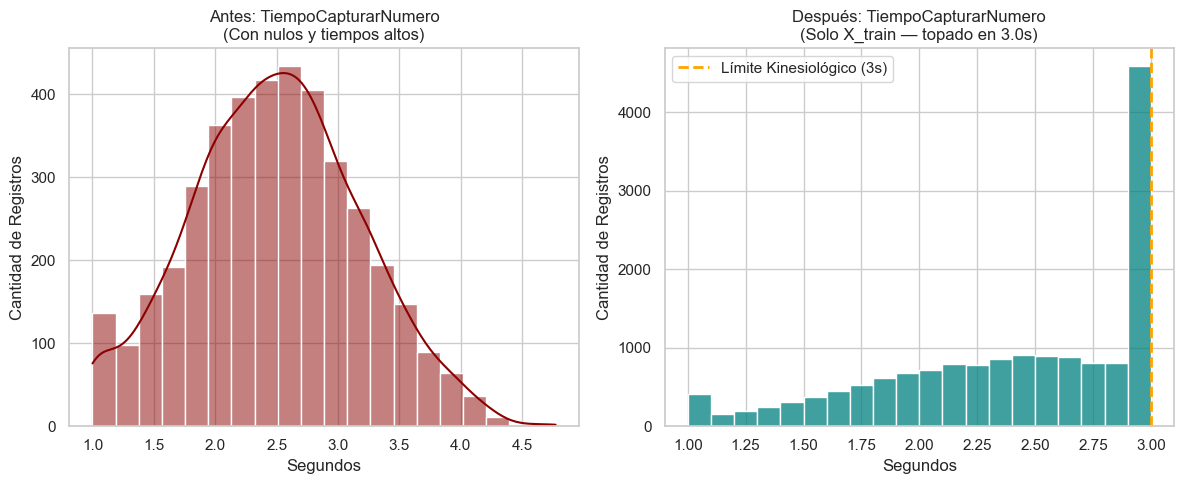

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
# Configurar el estilo del gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# Elegimos una columna para auditar
columna_a_revisar = 'TiempoCapturarNumero'

#  Gráfico de la izquierda: Datos Originales (Antes del filtro)

plt.subplot(1, 2, 1)
sns.histplot(df[columna_a_revisar], kde=True, color="darkred", bins=20)
plt.title(f"Antes: {columna_a_revisar}\n(Con nulos y tiempos altos)")
plt.xlabel("Segundos")
plt.ylabel("Cantidad de Registros")

# 2. Gráfico de la derecha: Datos Procesados (Después del filtro de 3 segundos)

plt.subplot(1, 2, 2)
sns.histplot(X_train[columna_a_revisar], kde=False, color="teal", bins=20)
plt.axvline(x=3.0, color="orange", linestyle="--", linewidth=2, label="Límite Kinesiológico (3s)")
plt.title(f"Después: {columna_a_revisar}\n(Solo X_train — topado en 3.0s)")
plt.xlabel("Segundos")
plt.ylabel("Cantidad de Registros")
plt.legend()

plt.tight_layout()
plt.show()

In [32]:
from tensorflow.keras.callbacks import EarlyStopping

# Compilar el modelo
modelo_base.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Entrenar con Early Stopping
historial = modelo_base.fit(
    X_train_tensor,
    y_train_tensor,
    epochs=100,              # Máximo 200, pero parará antes si no mejora
    batch_size=64,
    validation_split=0.2,
    callbacks=[],
    verbose=1
)

print(f" Entrenamiento detenido en epoch: {len(historial.history['loss'])}")

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5981 - loss: 0.6662 - val_accuracy: 0.6819 - val_loss: 0.6158
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6706 - loss: 0.6207 - val_accuracy: 0.6897 - val_loss: 0.5960
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6839 - loss: 0.6079 - val_accuracy: 0.6850 - val_loss: 0.5950
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6829 - loss: 0.6066 - val_accuracy: 0.6894 - val_loss: 0.5939
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6823 - loss: 0.6058 - val_accuracy: 0.6888 - val_loss: 0.5931
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6898 - loss: 0.6031 - val_accuracy: 0.6878 - val_loss: 0.5931
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6859 - loss: 0.6019 - val_accuracy: 0.6938 - val_loss: 0.5928
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6862 - loss: 0.6031 - val_accu